In [24]:
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from battleship.scoring import compute_score, compute_score_parallel
from battleship.prompting import HUMAN_DATASET_PATH
from battleship.board import Board

# Configure matplotlib for retina display
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Configure seaborn
sns.set_theme(style="whitegrid")

In [2]:
RESULTS_DIR = "results_official"

# Load the data

In [3]:
HUMAN_DATA_PATH = os.path.join(RESULTS_DIR, "human_question_dataset_scored.csv")

# Compute scores if they don't exist
if not os.path.exists(HUMAN_DATA_PATH):
    df_human = pd.read_csv(HUMAN_DATASET_PATH)
    df_human["score"] = [
        compute_score(program=program, board=Board.from_trial_id(trial_id))
        for program, trial_id in zip(df_human["code"], df_human["trial"])
    ]
    df_human["model"] = "Human"
    df_human.to_csv(HUMAN_DATA_PATH, index=False)
else:
    df_human = pd.read_csv(HUMAN_DATA_PATH)

df_human = df_human.rename(columns={"trial": "trial_id", "code": "program"})
df_human

,trial_id,question,program,score,model
0,1,Are all ships horizontal?,(all (map (lambda x0 (== (orient x0) H)) (set ...,0.470937,Human
1,1,Are any of the ships touching?,(or (or (touch Blue Purple) (touch Purple Red)...,0.988805,Human
2,1,Are any ships 2 tiles long?,(any (map (lambda x0 (== (size x0) 2)) (set Al...,0.378446,Human
3,1,At what location is the top left part of the r...,(topleft (coloredTiles Red)),4.669496,Human
4,1,At what location is the top left part of the r...,(topleft (coloredTiles Red)),4.669496,Human
...,...,...,...,...,...
600,18,Is there a purple tile at 1A?,(== (color 1A) Purple),0.954434,Human
601,18,Is there a purple tile at 2C?,(== (color 2C) Purple),0.811278,Human
602,18,Is there any part of the purple ship in column B?,(any (map (lambda y0 (== (colL y0) 2)) (colore...,0.954434,Human
603,18,What color is at 1A?,(color 1A),0.954434,Human


In [4]:
df_codellama_7b = pd.read_csv(os.path.join(RESULTS_DIR, "CodeLlama-7b-hf-2024-01-23-04-52-40", "results_corrected.csv"))
df_codellama_7b["model"] = "CodeLlama-7b"
# rename completion -> question and translation -> program
df_codellama_7b = df_codellama_7b.rename(columns={"completion": "question", "translation": "program"})
df_codellama_7b

,trial_id,question,program,score,type,prompt_id,model
0,1,How many tiles is the purple ship?,(size Purple),1.360775,final,0,CodeLlama-7b
1,1,What color is at 2F?,(color 2F),1.418245,final,0,CodeLlama-7b
2,1,Is the red ship horizontal?,(== (orient Red) H),0.993542,final,0,CodeLlama-7b
3,1,Is there a water tile at 3D?,(== (color 3D) Water),-0.000000,final,0,CodeLlama-7b
4,1,Is there a ship at 2F?,(color 2F),1.418245,final,0,CodeLlama-7b
...,...,...,...,...,...,...,...
1795,18,What color is at 1B?,(at 1 B),NaN,final,19,CodeLlama-7b
1796,18,Is the purple ship 4 tiles long?,(== (size Purple) 4),0.811278,final,19,CodeLlama-7b
1797,18,What color is at 5B?,(at 5B),NaN,final,19,CodeLlama-7b
1798,18,How many tiles is the blue ship?,(size Blue),-0.000000,final,19,CodeLlama-7b


In [5]:
df_gpt4 = pd.read_csv(os.path.join(RESULTS_DIR, "gpt4-2024-01-23-21-53-34", "results.csv"))
df_gpt4["model"] = "GPT-4"
df_gpt4

,trial_id,prompt_id,question,program,score,model
0,1,0,Is there a ship at 2B?,(exists (color 2B)),NaN,GPT-4
1,1,1,Is there a ship at 4D?,(exists (coloredTiles AllColors) 4D),NaN,GPT-4
2,1,2,Is there a red ship at 5E?,(== (color 5E) Red),0.309409,GPT-4
3,1,3,How many tiles is the red ship?,(size Red),1.360775,GPT-4
4,1,4,What color is at 1A?,(color 1A),1.136443,GPT-4
...,...,...,...,...,...,...
175,18,5,Is the purple ship horizontal?,(== (orient Purple) H),0.954434,GPT-4
176,18,6,Is the purple ship horizontal?,(== (orient Purple) H),0.954434,GPT-4
177,18,7,Is the red ship vertical?,(== (orient Red) V),-0.000000,GPT-4
178,18,8,How many tiles is the purple ship?,(size Purple),1.561278,GPT-4


In [18]:
df_grammar_sampling = pd.read_csv(os.path.join(RESULTS_DIR, "grammar-sampling-2024-01-22", "sampling_data.csv"))
df_grammar_sampling = df_grammar_sampling.rename(columns={"board_id": "trial_id"})
df_grammar_sampling = df_grammar_sampling[["trial_id", "program", "score", "depth"]]
df_grammar_sampling["model"] = "Grammar (sampling)"
df_grammar_sampling

,trial_id,program,score,depth,model
0,1,( not ( == ( + ( == 0 1 ) ( or TRUE ( == ( == ...,-0.000000,8,Grammar (sampling)
1,1,( and ( == 4 ( - ( colL 5C ) 1 ) ) ( or ( == V...,-0.000000,5,Grammar (sampling)
2,1,( + ( == ( + 2 ( size Red ) ) 3 ) ( == H ( ori...,0.993542,5,Grammar (sampling)
3,1,( < ( + ( touch Red Blue ) TRUE ) ( + ( rowL 1...,0.756291,11,Grammar (sampling)
4,1,( == ( and ( == ( color 4A ) Water ) ( > ( col...,-0.000000,5,Grammar (sampling)
...,...,...,...,...,...
1799995,18,( + ( and ( touch Blue Red ) ( == 4 ( colL 5F ...,-0.000000,9,Grammar (sampling)
1799996,18,( - ( setSize ( coloredTiles Water ) ) ( + ( =...,1.561278,9,Grammar (sampling)
1799997,18,( and ( or ( or FALSE ( and ( == H ( orient Pu...,-0.000000,12,Grammar (sampling)
1799998,18,( setSize ( intersection ( intersection ( setD...,-0.000000,7,Grammar (sampling)


In [19]:
df_grammar_enumeration = pd.read_csv(os.path.join(RESULTS_DIR, "grammar-enumeration-2024-01-22", "enumeration_data.csv"))
df_grammar_enumeration = df_grammar_enumeration.rename(columns={"board_id": "trial_id"})
df_grammar_enumeration = df_grammar_enumeration[["trial_id", "program", "score"]]
df_grammar_enumeration["model"] = "Grammar (enumeration)"
df_grammar_enumeration

,trial_id,program,score,model
0,1,TRUE,-0.0,Grammar (enumeration)
1,1,FALSE,-0.0,Grammar (enumeration)
2,1,( not TRUE ),-0.0,Grammar (enumeration)
3,1,( not FALSE ),-0.0,Grammar (enumeration)
4,1,( not ( not TRUE ) ),-0.0,Grammar (enumeration)
...,...,...,...,...
1799995,18,( and ( < 8 0 ) ( == 1 5 ) ),-0.0,Grammar (enumeration)
1799996,18,( and ( < 8 0 ) ( == 1 6 ) ),-0.0,Grammar (enumeration)
1799997,18,( and ( < 8 0 ) ( == 1 7 ) ),-0.0,Grammar (enumeration)
1799998,18,( and ( < 8 0 ) ( == 1 8 ) ),-0.0,Grammar (enumeration)


# Merge datasets

In [20]:
df = pd.concat([df_human, df_codellama_7b, df_gpt4, df_grammar_sampling, df_grammar_enumeration]).reset_index(drop=True)
df

,trial_id,question,program,score,model,type,prompt_id,depth
0,1,Are all ships horizontal?,(all (map (lambda x0 (== (orient x0) H)) (set ...,0.470937,Human,NaN,NaN,NaN
1,1,Are any of the ships touching?,(or (or (touch Blue Purple) (touch Purple Red)...,0.988805,Human,NaN,NaN,NaN
2,1,Are any ships 2 tiles long?,(any (map (lambda x0 (== (size x0) 2)) (set Al...,0.378446,Human,NaN,NaN,NaN
3,1,At what location is the top left part of the r...,(topleft (coloredTiles Red)),4.669496,Human,NaN,NaN,NaN
4,1,At what location is the top left part of the r...,(topleft (coloredTiles Red)),4.669496,Human,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
3602580,18,NaN,( and ( < 8 0 ) ( == 1 5 ) ),-0.000000,Grammar (enumeration),NaN,NaN,NaN
3602581,18,NaN,( and ( < 8 0 ) ( == 1 6 ) ),-0.000000,Grammar (enumeration),NaN,NaN,NaN
3602582,18,NaN,( and ( < 8 0 ) ( == 1 7 ) ),-0.000000,Grammar (enumeration),NaN,NaN,NaN
3602583,18,NaN,( and ( < 8 0 ) ( == 1 8 ) ),-0.000000,Grammar (enumeration),NaN,NaN,NaN


# EIG comparison

### Summary stats

In [44]:
aggregators = {
    "mean": "mean",
    "max": "max",
    "count": "count",
    "valid": lambda x: x.count() / len(x),
    "nonzero": lambda x: (x > 0).sum() / len(x),
}

In [45]:
df_grouped_by_model = df.groupby(["model"]).score.agg(**aggregators)
df_grouped_by_model

,mean,max,count,valid,nonzero
model,,,,,
CodeLlama-7b,0.652393,4.726875,1344,0.746667,0.446667
GPT-4,0.761524,3.644671,167,0.927778,0.633333
Grammar (enumeration),0.003454,1.000000,1800000,1.000000,0.004933
Grammar (sampling),0.251079,4.784772,1800000,1.000000,0.238037
Human,1.268045,4.726875,605,1.000000,0.966942


In [46]:
df_grouped_by_trial = df.groupby(["trial_id", "model"]).score.agg(**aggregators)
df_grouped_by_trial

mean       max   count  valid   nonzero
trial_id model                                                             
1        CodeLlama-7b           1.122182  4.669496      72   0.72  0.620000
         GPT-4                  0.973028  1.360775       7   0.70  0.700000
         Grammar (enumeration)  0.005037  0.756291  100000   1.00  0.006660
         Grammar (sampling)     0.358231  4.686975  100000   1.00  0.322140
         Human                  1.433552  4.669496      30   1.00  1.000000
...                                  ...       ...     ...    ...       ...
18       CodeLlama-7b           0.251480  1.561278      71   0.71  0.180000
         GPT-4                  0.537901  1.561278      10   1.00  0.500000
         Grammar (enumeration)  0.001801  0.811278  100000   1.00  0.002220
         Grammar (sampling)     0.135548  2.500000  100000   1.00  0.122390
         Human                  1.078188  2.500000      36   1.00  0.972222

[90 rows x 5 columns]

In [73]:
df_main_results = df_grouped_by_trial.groupby(["model"])[list(aggregators.keys())].agg(["mean", "std"])
# flatten multiindex
df_main_results.columns = [col[1] if col[1] == "std" else col[0] for col in df_main_results.columns]
df_main_results = df_main_results.round(3)
df_main_results

,mean,std,max,std,count,std,valid,std,nonzero,std
model,,,,,,,,,,
CodeLlama-7b,0.657,0.237,2.760,1.287,74.667,3.742,0.747,0.037,0.447,0.122
GPT-4,0.773,0.325,1.661,0.590,9.278,1.018,0.928,0.102,0.633,0.257
Grammar (enumeration),0.003,0.001,0.771,0.225,100000.000,0.000,1.000,0.000,0.005,0.002
Grammar (sampling),0.251,0.057,4.019,0.635,100000.000,0.000,1.000,0.000,0.238,0.051
Human,1.274,0.172,3.611,1.078,33.611,3.632,1.000,0.000,0.966,0.028


In [74]:
# convert to markdown
print(df_main_results.to_markdown())

| model                 |   mean |   std |   max |   std |      count |   std |   valid |   std |   nonzero |   std |
|:----------------------|-------:|------:|------:|------:|-----------:|------:|--------:|------:|----------:|------:|
| CodeLlama-7b          |  0.657 | 0.237 | 2.76  | 1.287 |     74.667 | 3.742 |   0.747 | 0.037 |     0.447 | 0.122 |
| GPT-4                 |  0.773 | 0.325 | 1.661 | 0.59  |      9.278 | 1.018 |   0.928 | 0.102 |     0.633 | 0.257 |
| Grammar (enumeration) |  0.003 | 0.001 | 0.771 | 0.225 | 100000     | 0     |   1     | 0     |     0.005 | 0.002 |
| Grammar (sampling)    |  0.251 | 0.057 | 4.019 | 0.635 | 100000     | 0     |   1     | 0     |     0.238 | 0.051 |
| Human                 |  1.274 | 0.172 | 3.611 | 1.078 |     33.611 | 3.632 |   1     | 0     |     0.966 | 0.028 |


### Overall EIG distributions

<Axes: xlabel='model', ylabel='score'>

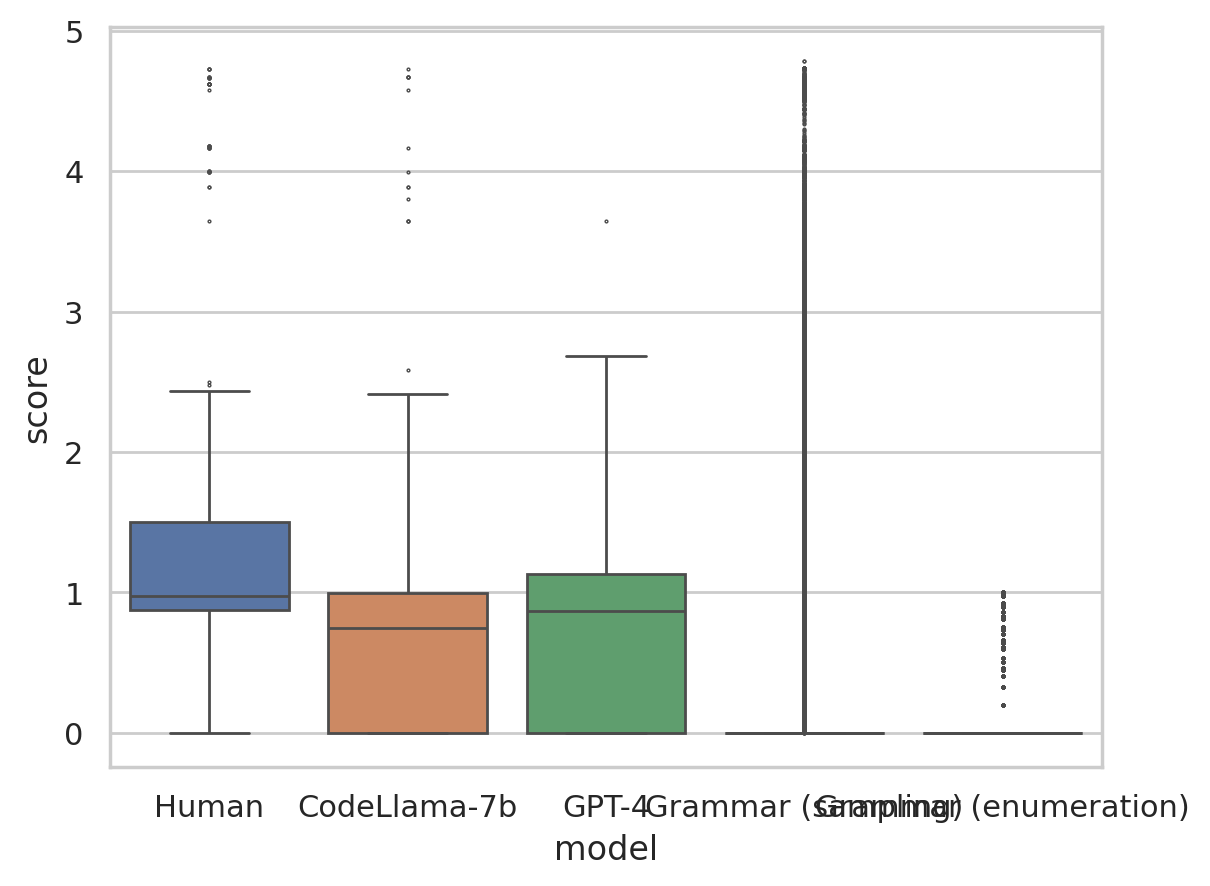

In [93]:
# histogram of score distributions
sns.boxplot(
    df,
    y="score",
    x="model",
    hue="model",
    fliersize=1.0,
    flierprops={"marker": "."},
)

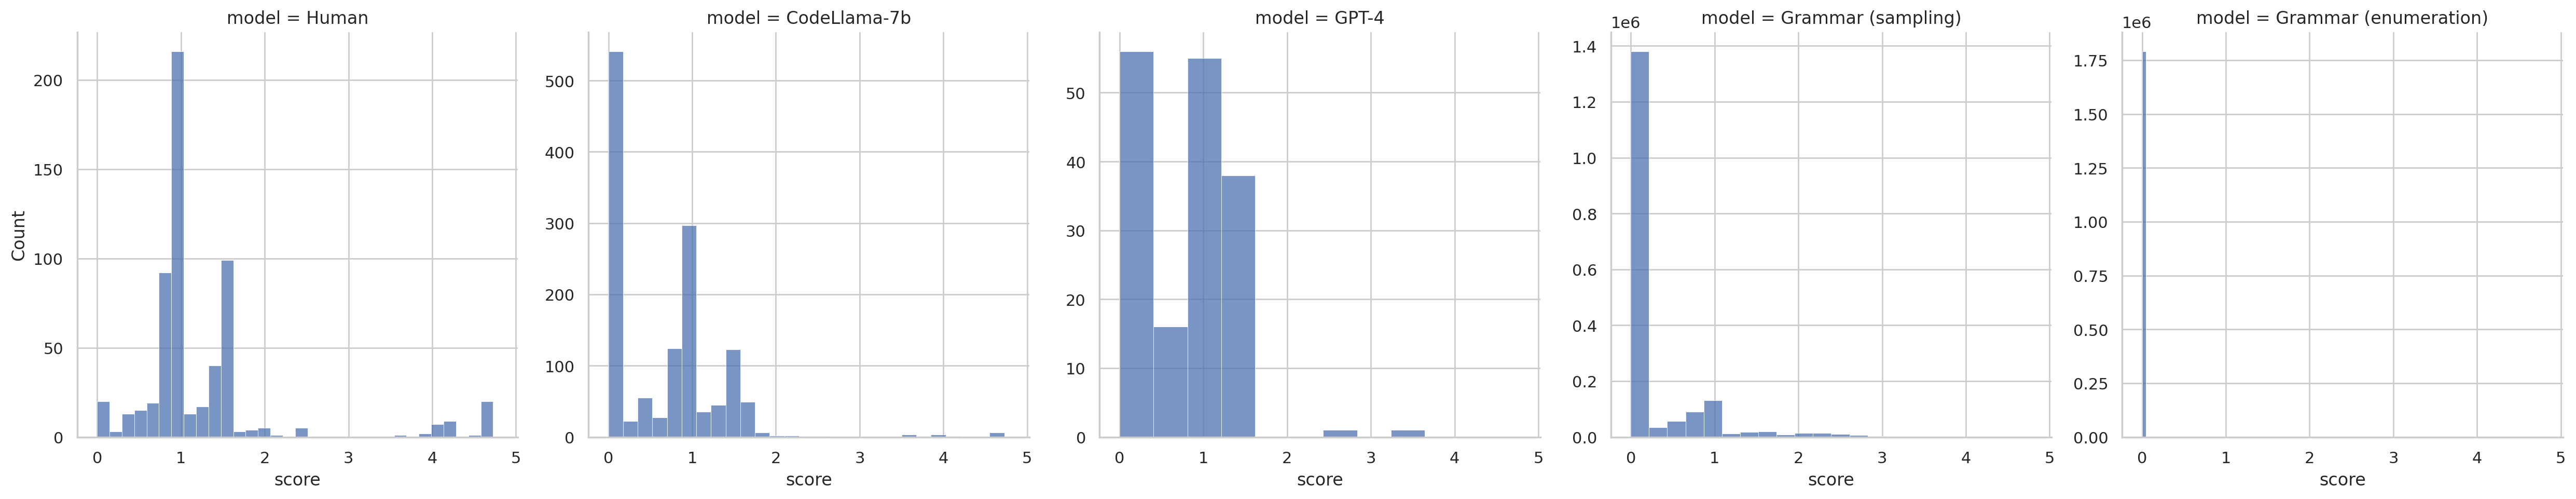

In [102]:
sns.displot(
    data=df,
    col="model",
    x="score",
    common_norm=False,
    common_bins=False,
    facet_kws=dict(sharey=False)
)

### Grouped by trial

Text(0, 0.5, 'EIG')

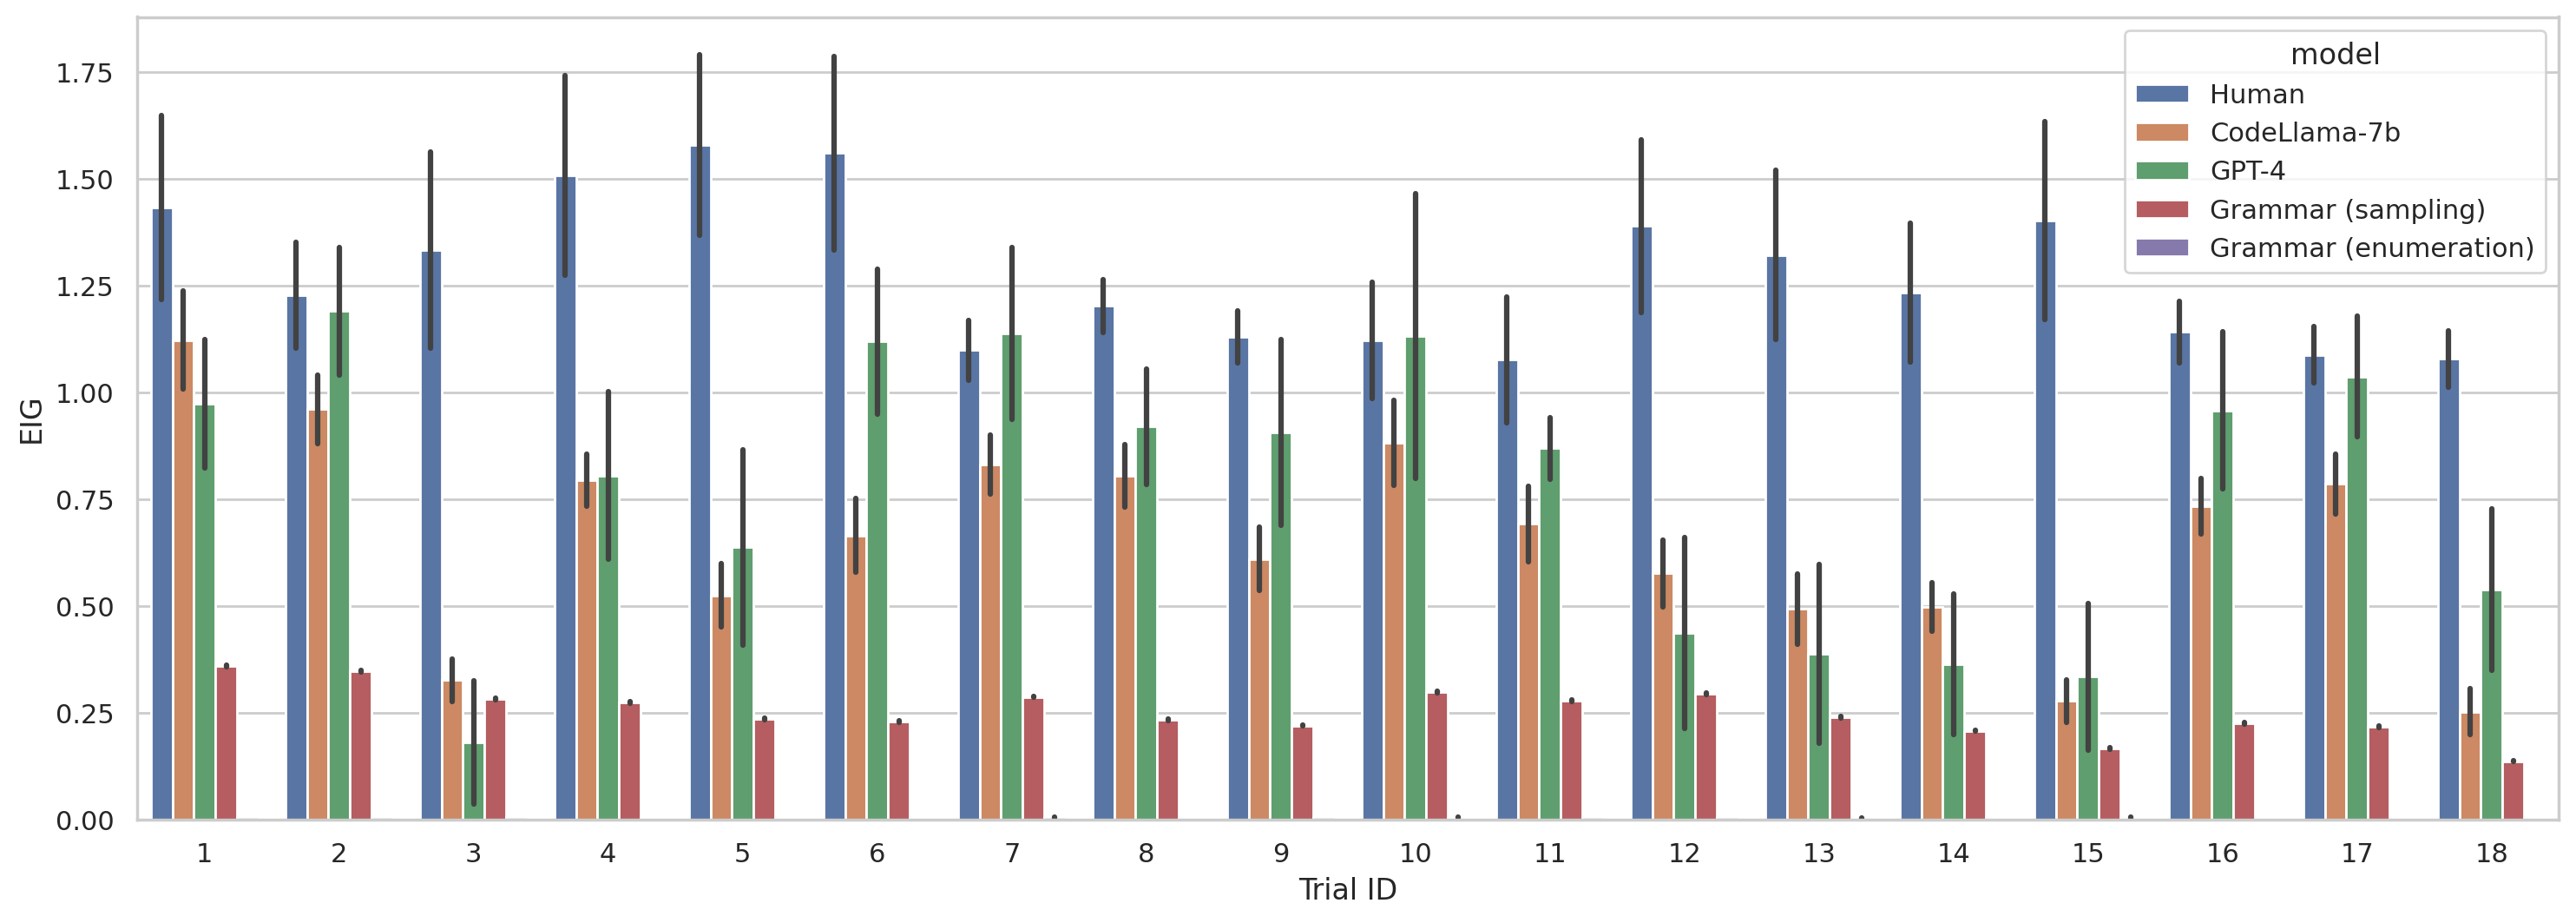

In [30]:
plt.figure(figsize=(18, 6))
sns.barplot(data=df, hue="model", x="trial_id", y="score", errorbar="se")
plt.xlabel("Trial ID")
plt.ylabel("EIG")

Text(0, 0.5, 'EIG')

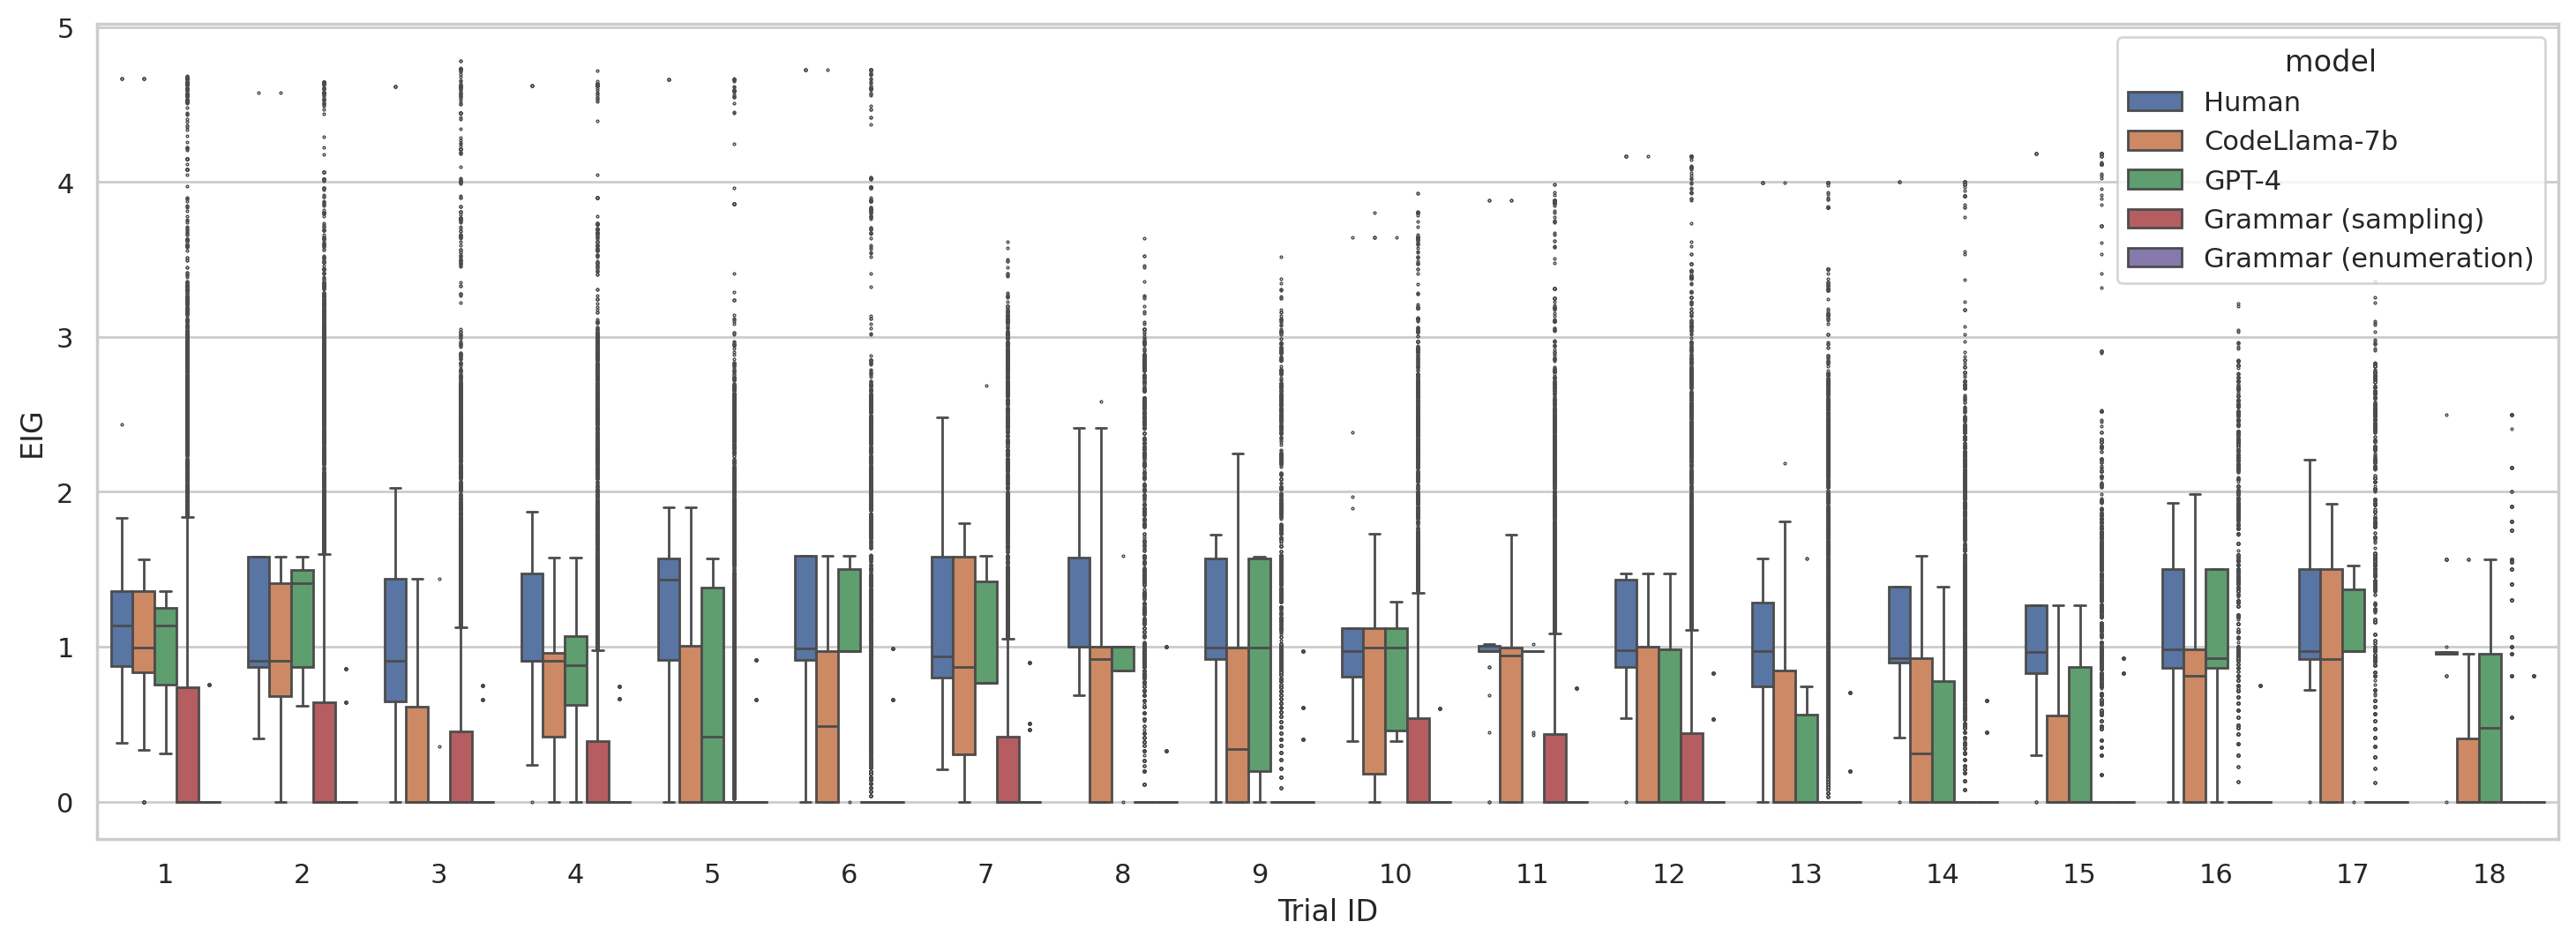

In [83]:
plt.figure(figsize=(18, 6))
# sns.boxplot(data=df, hue="model", x="trial_id", y="score", showfliers=False)
sns.boxplot(
    data=df,
    hue="model",
    x="trial_id",
    y="score",
    fliersize=1.0,
    flierprops={"marker": "."},
)
plt.xlabel("Trial ID")
plt.ylabel("EIG")

<Axes: xlabel='trial_id', ylabel='score'>

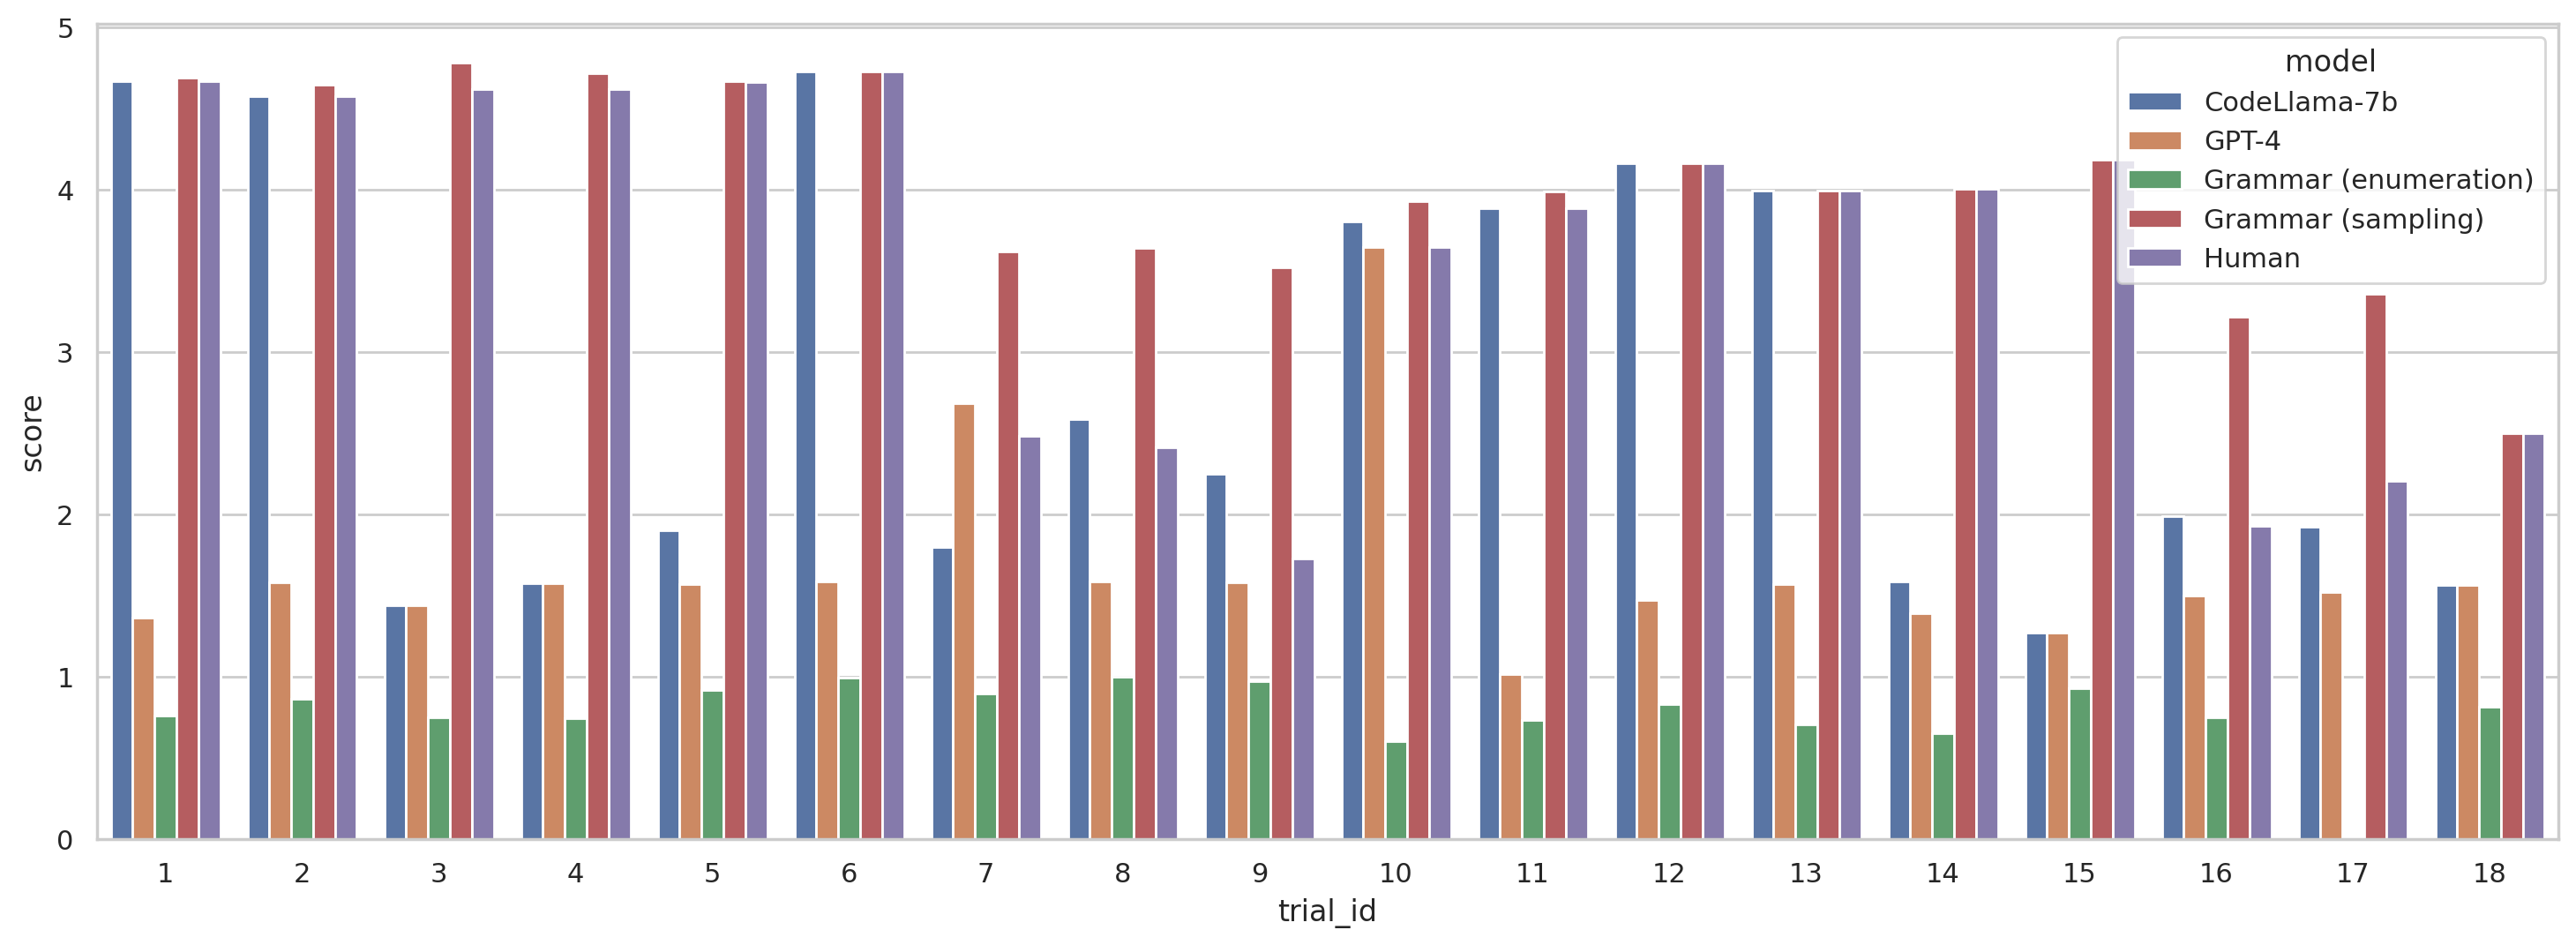

In [31]:
df_max = df.groupby(["model", "trial_id"]).score.agg("max")

plt.figure(figsize=(18, 6))
sns.barplot(data=df_max.reset_index(), x="trial_id", y="score", hue="model")